In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## Load and transform run

In [2]:
FOLDER = "18-03-26--14_05_58/mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-01d9-4d43-b404-3b7214b30d77}.pkl"

data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
# data_dir = REPO_ROOT / "experiment" / "data" / "sample"
if FOLDER:
    data_dir = data_dir / FOLDER

run = load_run(data_dir)

# Normalize units: wei → ETH, ratio → %
run = normalize_run(run)
res = merge_runs([run])

## Plots

### Plot: plot_accuracy_loss_over_rounds

,experiment_id,round,round_time,objective_global_accuracy,objective_global_loss,reward_pool,punishment_pool,is_baseline
0,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,0,0.000000,0.0775,721.124648,1.0,0.000000,True
1,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,1,67.491629,0.1195,717.659065,0.8,0.000000,False
2,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,2,66.264732,0.4209,683.068233,0.6,0.000000,False
3,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,3,57.996800,0.7790,230.971950,0.4,0.711111,False
4,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,4,60.737068,0.8565,151.855022,0.2,0.474074,False
5,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,5,63.538728,0.8846,119.331565,0.0,0.316049,False


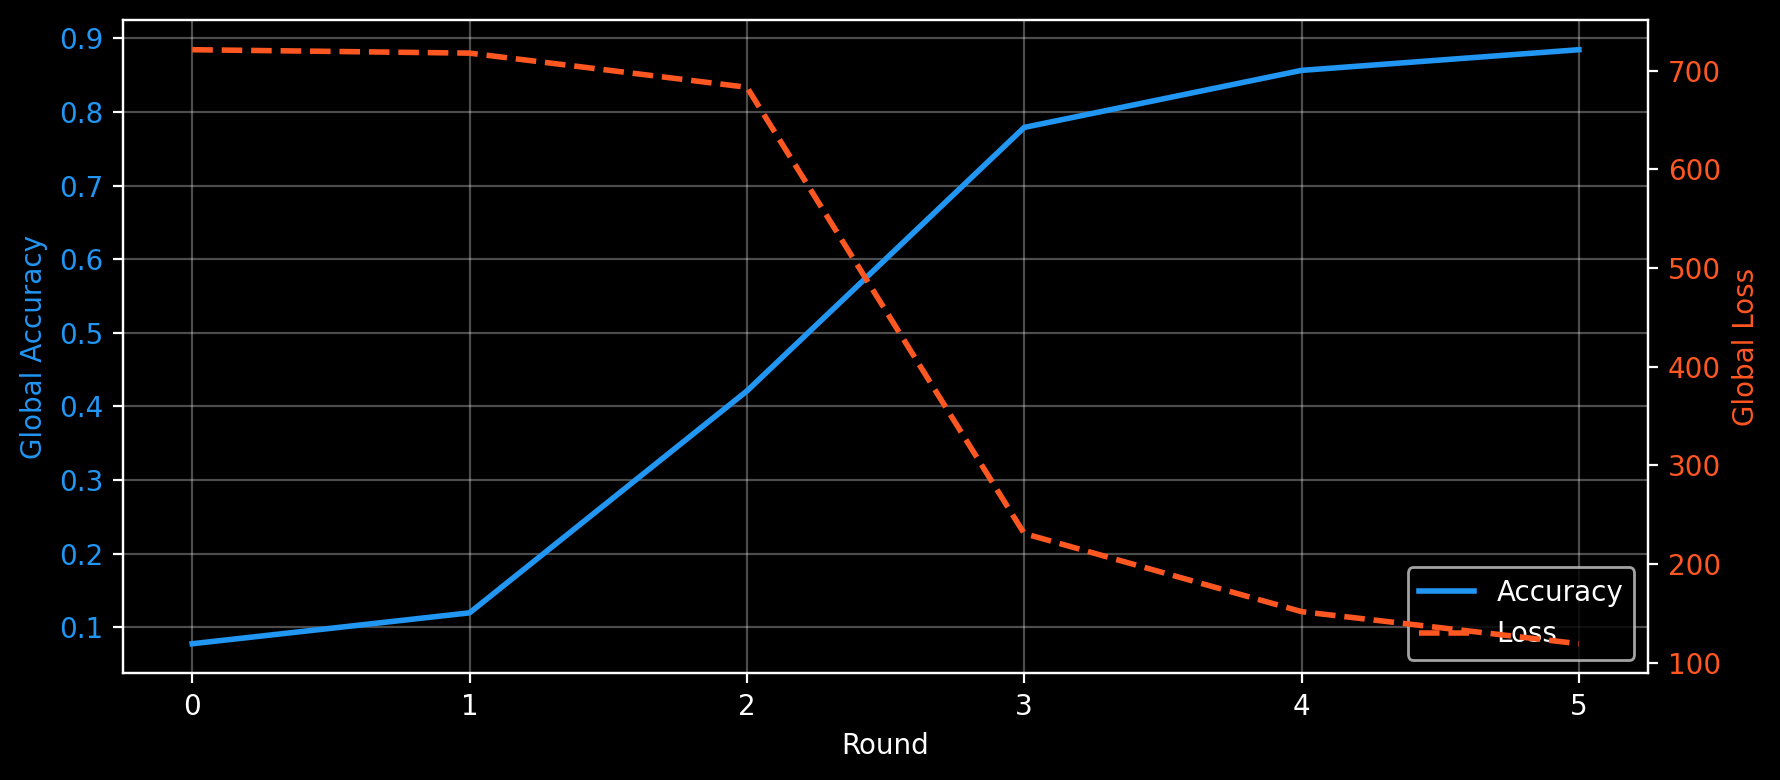

In [3]:
data = res['global']
aggregated = agg_global_accuracy_loss_by_round(data)

fig = plot_accuracy_loss_over_rounds(aggregated) # Assign since it otherwise will plot twice.
data

### Plot: plot_gas_cost_by_tx_type

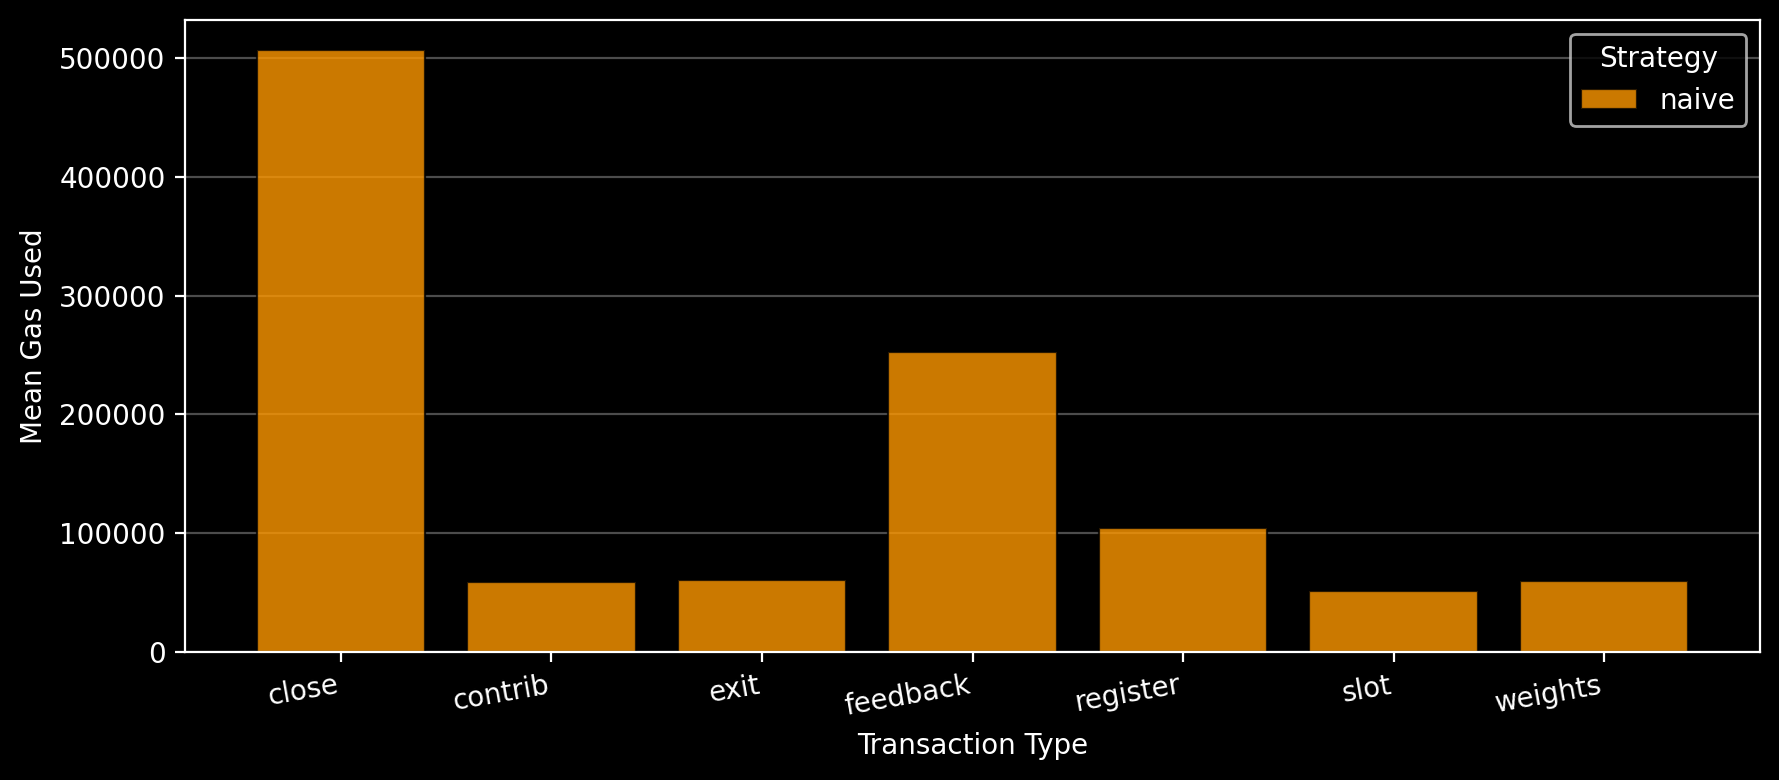

In [4]:
# plot_round_kicked_by_strategy(aggregated)
data = res['receipts']
aggregated = agg_gas_used_by_tx_type(data, res['metadata'])
fig = plot_gas_cost_by_tx_type(aggregated)

  ┌──────────────────────────────────────┬──────────────────────────────────┐
  │             Aggregation              │               Plot               │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_global_accuracy_by_round         │ plot_accuracy_loss_over_rounds   │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_accuracy_by_strategy             │ plot_strategy_comparison_lines   │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_final_round_accuracy_by_strategy │ plot_strategy_comparison_boxplot │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_grs_by_behavior                  │ plot_grs_by_behavior             │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_gas_used_by_tx_type              │ plot_gas_cost_by_tx_type         │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_round_kicked_by_strategy         │ plot_round_kicked_by_strategy    │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_contribution_score_by_behavior   │ (no corresponding plot)          │
  └──────────────────────────────────────┴──────────────────────────────────┘

### Plot: plot_round_kicked_by_strategy

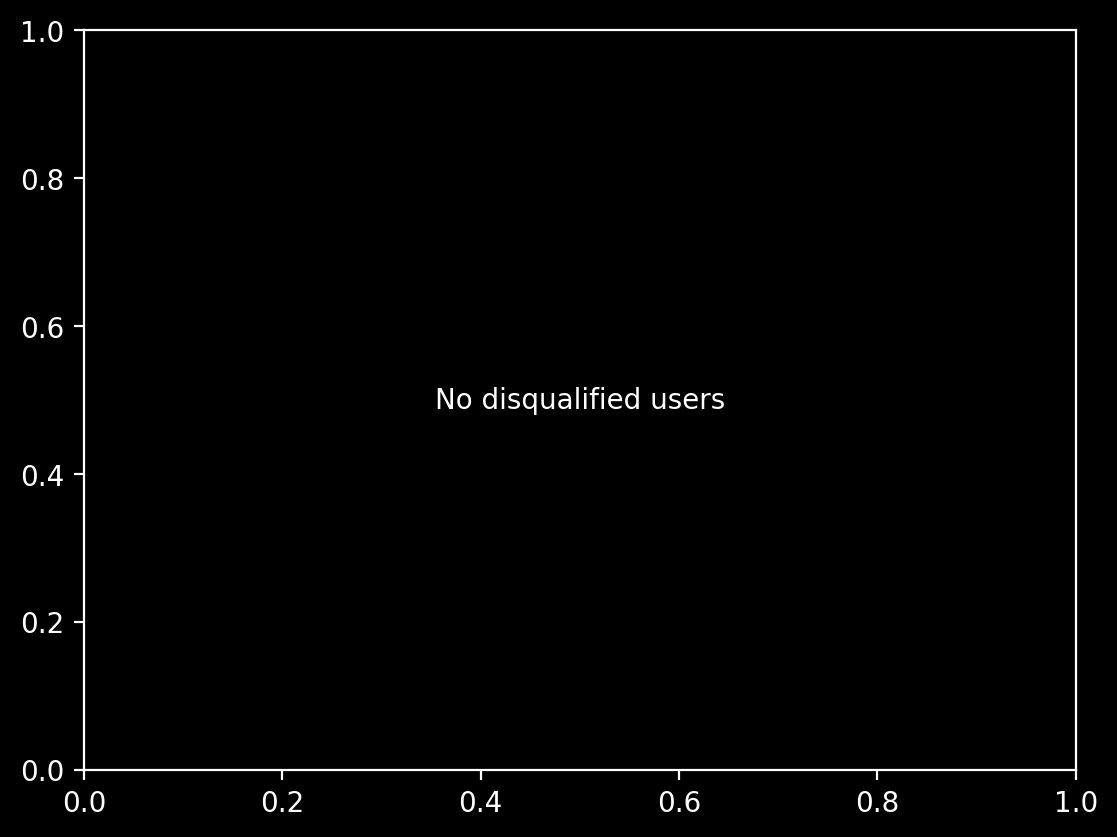

In [5]:
data = res['users']
aggregated = agg_round_kicked_by_strategy(data, res['metadata'])
fig = plot_round_kicked_by_strategy(aggregated)

## Plot: Agg. GRS by role

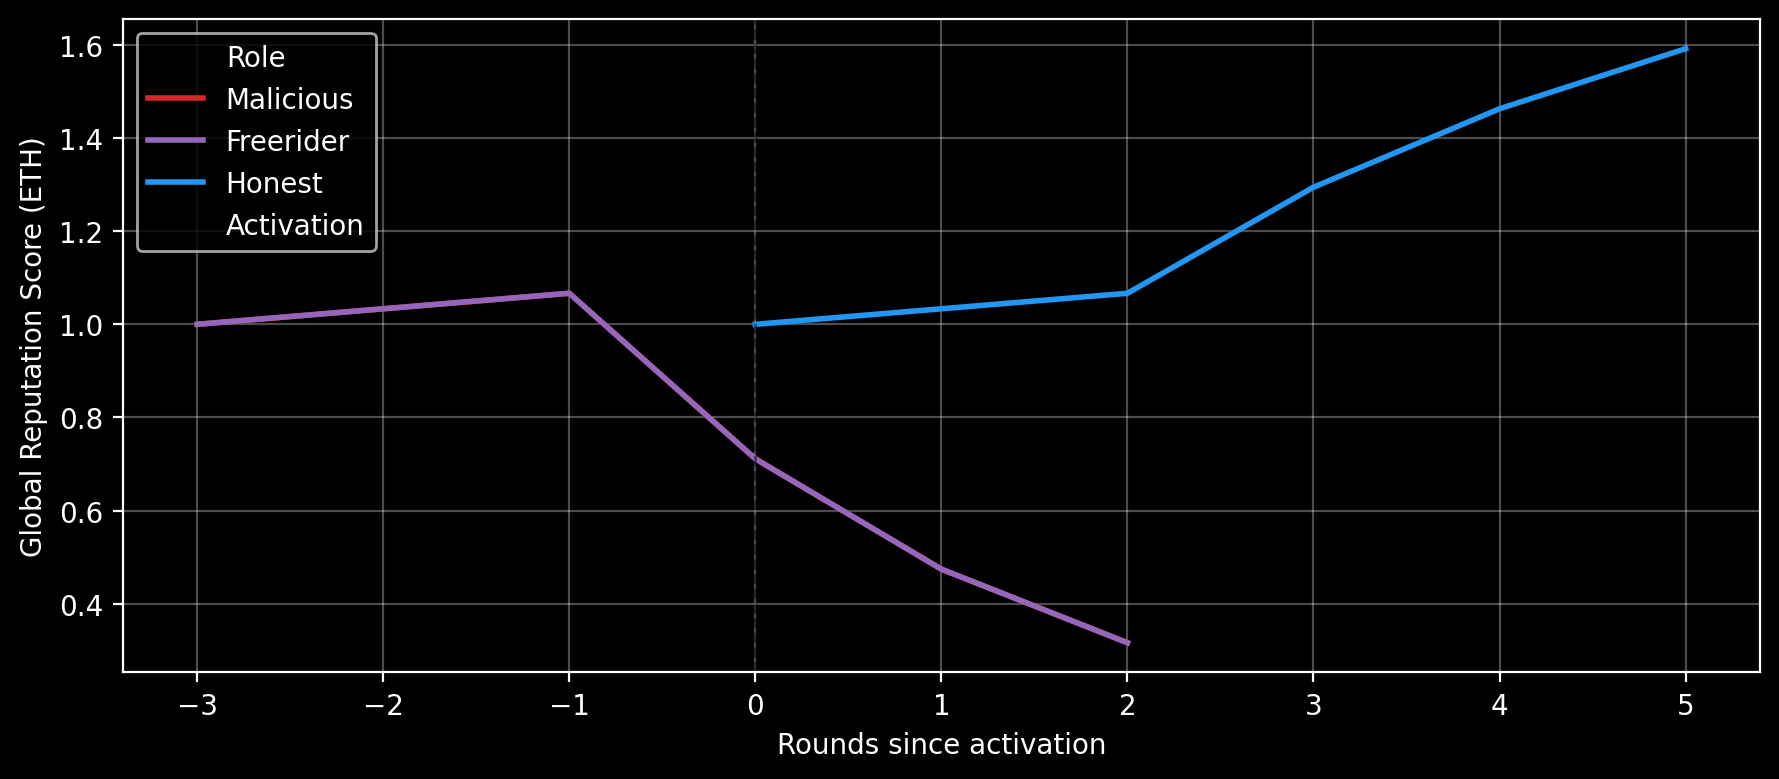

In [6]:
data = res['users']
aggregated = agg_grs_by_role_relative(data, res['metadata'])
fig = plot_grs_by_role_relative(aggregated)


# Why are they not equal at round 3

## Plot: GRS by user

,experiment_id,round,user_id,state,behavior,role,grs,subjective_personal_accuracy,subjective_personal_loss,subjective_global_accuracy,subjective_global_loss,round_reputation_assigned,reward_delta,is_reward,merged
4,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,0,4,active,good,bad,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,None,None
10,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,1,4,active,good,bad,1.033333,0.631,58.335450,0.6318,569.264462,1.000000e+18,0.033333,True,True
16,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,2,4,active,good,bad,1.066667,0.305,70.082001,0.3063,685.559693,2.066667e+18,0.033333,True,True
22,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,3,4,active,bad,bad,0.711111,0.305,70.082001,0.4209,683.068233,-4.266667e+18,NaN,None,False
28,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,4,4,active,bad,bad,0.474074,0.305,70.082001,0.7790,230.971950,-5.177778e+18,NaN,None,False
34,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,5,4,active,bad,bad,0.316049,0.305,70.082001,0.8565,151.855022,-5.851852e+18,NaN,None,False
5,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,0,5,active,good,freerider,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,None,None
11,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,1,5,active,good,freerider,1.033333,0.767,57.707825,0.7273,569.887774,5.000000e+18,0.033333,True,True
17,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,2,5,active,good,freerider,1.066667,0.435,69.610609,0.4070,683.574722,5.166667e+18,0.033333,True,True
23,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,3,5,active,freerider,freerider,0.711111,0.435,69.610609,0.4209,683.068233,-5.333333e+18,NaN,None,False


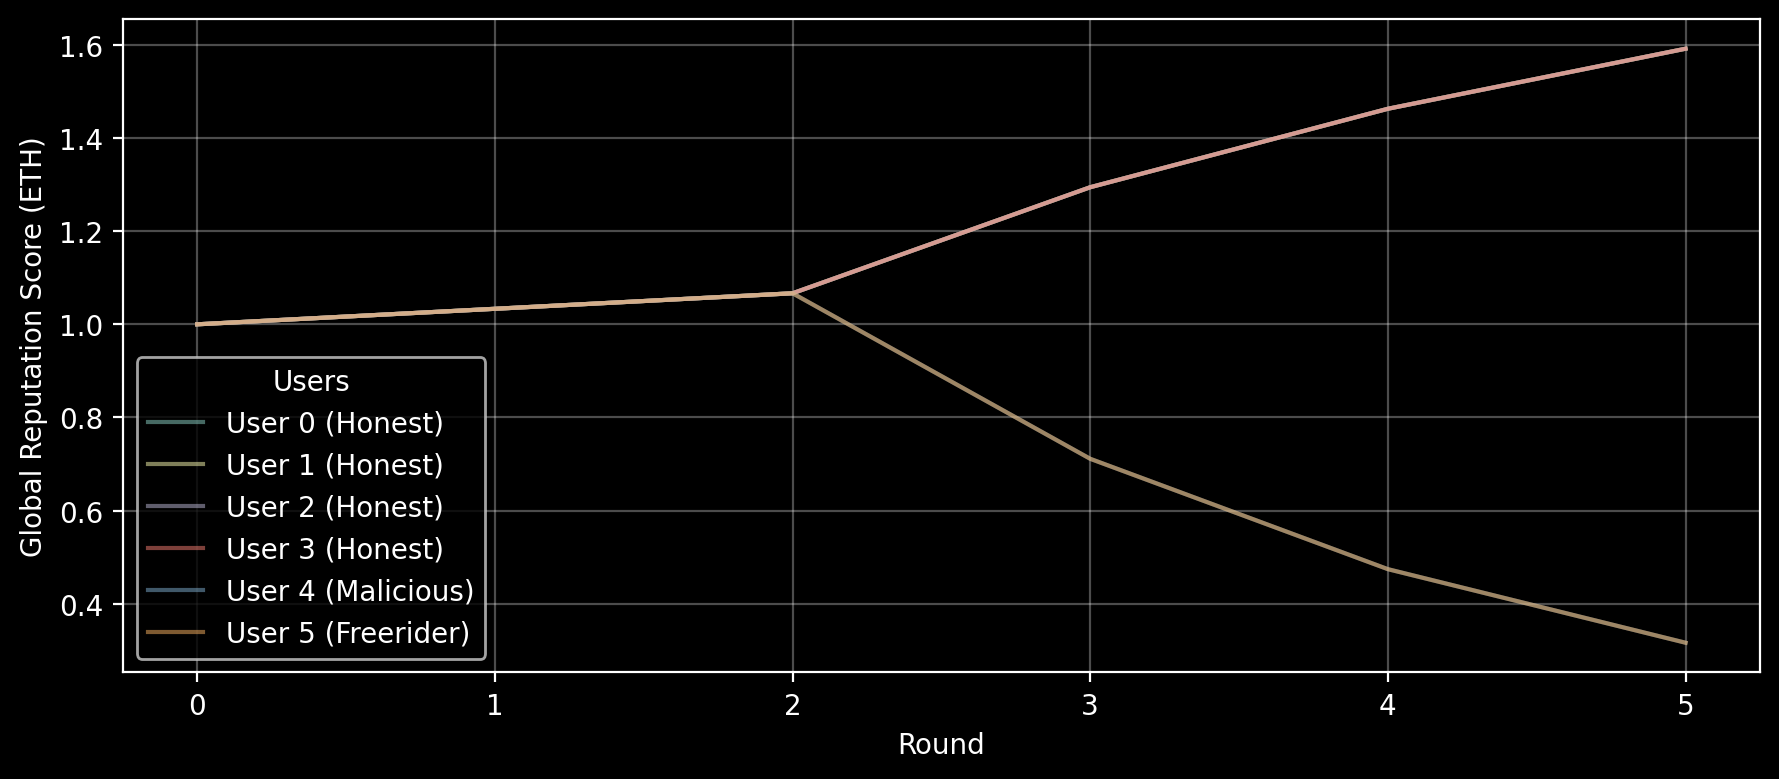

In [7]:
data = res['users']

# data[['grs', 'user_id', 'round']]

vals = grs_by_user(data)

fig = plot_grs_by_user(vals)

data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])


In [8]:
data[data['behavior'] == 'good'].groupby('round')[['subjective_personal_accuracy', 'grs']].mean()

# data[data['behavior'] == 'good'] & (data['state'] == 'disqualified')

# data[(data['behavior'] == 'good') & (data['state'] == 'disqualified')]


,subjective_personal_accuracy,grs
round,,
0,NaN,1.000000
1,0.705833,1.033333
2,0.361167,1.066667
3,0.738000,1.294444
4,0.829750,1.462963
5,0.866500,1.591975


In [9]:
data.sort_values('round')


# data = res['votes']
# data[['giver_id', 'giver_address']].drop_duplicates()

# data[data['user_id'] == 0]


data[data['round'] > 2].sort_values(['user_id', 'round'])

,experiment_id,round,user_id,state,behavior,role,grs,subjective_personal_accuracy,subjective_personal_loss,subjective_global_accuracy,subjective_global_loss,round_reputation_assigned,reward_delta,is_reward,merged
18,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,3,0,active,good,good,1.294444,0.714,27.585887,0.7285,261.456171,2.133333e+18,0.227778,True,True
24,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,4,0,active,good,good,1.462963,0.824,17.895102,0.8212,176.285861,3.172222e+18,0.168519,True,True
30,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,5,0,active,good,good,1.591975,0.856,13.857722,0.8647,137.761590,3.914815e+18,0.129012,True,True
19,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,3,1,active,good,good,1.294444,0.737,24.821830,0.7562,239.344832,2.133333e+18,0.227778,True,True
25,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,4,1,active,good,good,1.462963,0.845,16.594076,0.8348,164.521145,3.172222e+18,0.168519,True,True
31,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,5,1,active,good,good,1.591975,0.874,13.136940,0.8717,128.859841,3.914815e+18,0.129012,True,True
20,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,3,2,active,good,good,1.294444,0.759,24.885285,0.7607,238.673268,2.133333e+18,0.227778,True,True
26,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,4,2,active,good,good,1.462963,0.824,17.693766,0.8314,166.760523,3.172222e+18,0.168519,True,True
32,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,5,2,active,good,good,1.591975,0.881,13.385189,0.8788,126.845813,3.914815e+18,0.129012,True,True
21,mnist-naive-3-1.0-3-1.0-True-False-{9cdd156c-0...,3,3,active,good,good,1.294444,0.742,26.518896,0.7428,242.939322,2.133333e+18,0.227778,True,True


## Plot: Contribution score by role

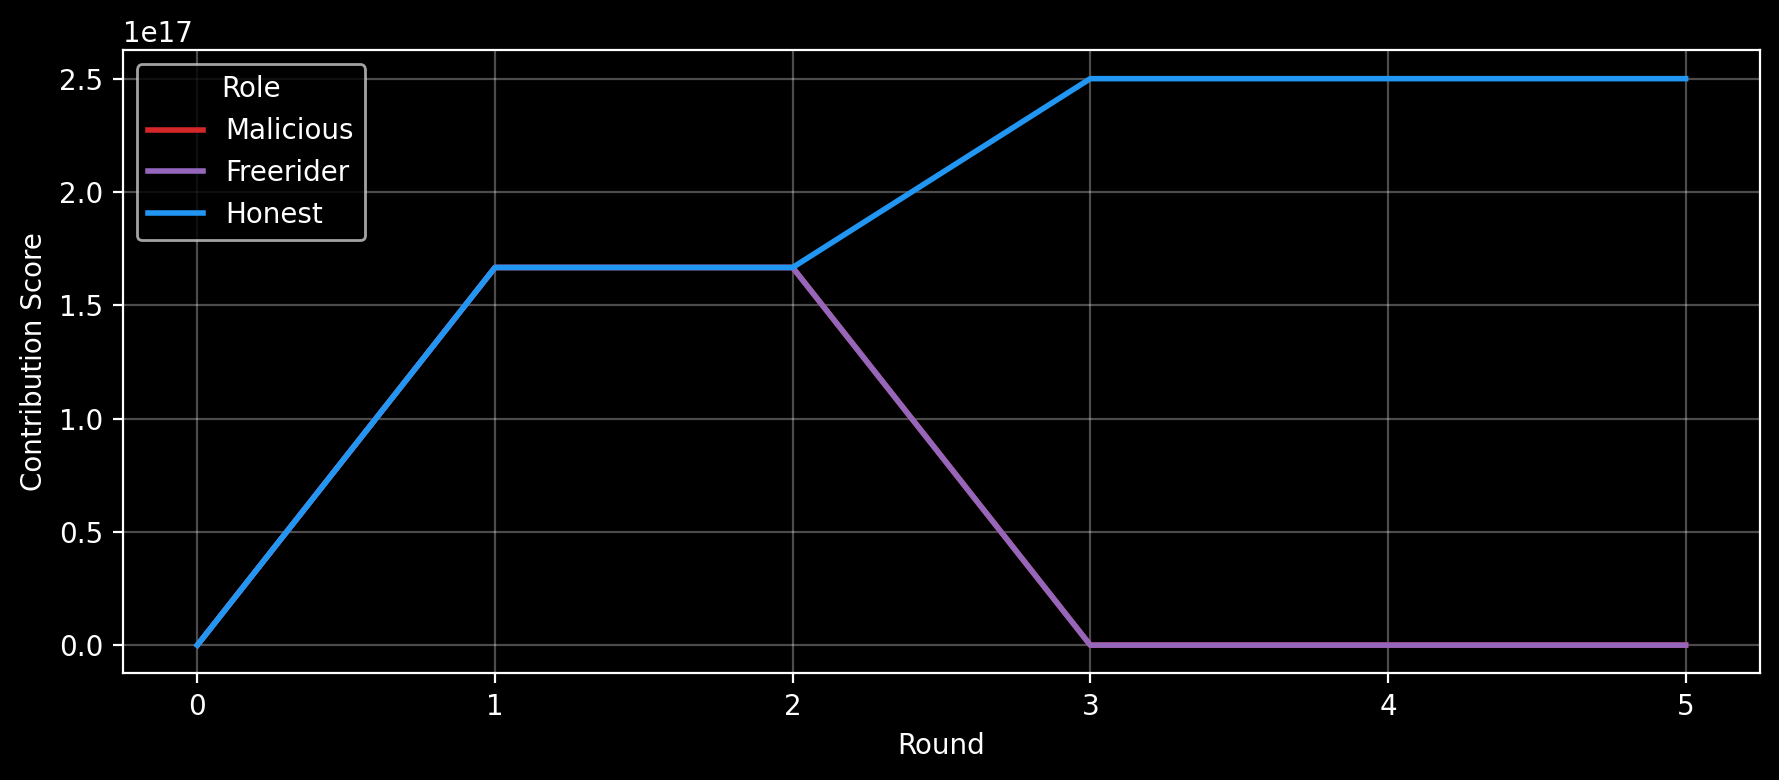

In [10]:
u = res['users']
c = res['contributions']

agg = agg_contribution_score_by_role(u, c, res['metadata'])
fig = plot_contribution_score_by_role(agg)